In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy

from scipy.optimize import curve_fit

from scipy.integrate import quad

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [6]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [7]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10_dk0_kmax10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10_1 = pickle.load(f)

In [8]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10_dk0_kmax10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10_1 = pickle.load(f)

In [9]:
len1 = len(Pk_gal10_1["k"])

In [10]:
ks1 = Pk_gal10_1["k"]

In [11]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [12]:
def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

In [13]:
def cf_nl_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    cf[mask] = -1
    return cf

In [14]:
def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return xi_d

In [15]:
def pk_from_cf(logks):
    rmax = 205
    dr=0.001
    r_list = np.arange(1e-4,rmax,dr)
    cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [16]:
def pk_from_cf_nl(logks):
    rmax = 1000
    dr=0.1
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_nl_excl(r_list, bias=2, R=0.37)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [17]:
logks_tng = np.log10(Pk_gal10["k"])
ks_tng = Pk_gal10["k"]
coef_k = (ks_tng**3)/(2*np.pi**2)

In [18]:
pk_fit = pk_from_cf(logks_tng)

In [19]:
popt = np.array([6.16619035e+14, 3.64190401e-03, 5.00000000e-01, 1.05736681e+00])

In [20]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos
    
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [21]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]
def uk_2_1halo(ks):
    uk = nfw_ft_numerical(ks, *popt)
    halo1 = (uk**2 * (shot_halo - shot_gal)) + shot_gal
    return halo1

In [22]:
uk = nfw_ft_numerical(ks_tng, *popt)

model_1halo = (uk**2 * (shot_halo - shot_gal)) + shot_gal

In [23]:
tng_1halo = np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])))
tng_2halo = np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))
tng_tot = np.log10((Pk_gal10["power"].real))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


In [24]:
# nmodes = Pk_gal10["modes"]
# err_gal_up = np.log10(Pk_gal10["power"].real + Pk_gal10["power"].real/np.sqrt(nmodes)) -  np.log10(Pk_gal10["power"].real)
# err_gal_down = np.log10(Pk_gal10["power"].real) - np.log10(Pk_gal10["power"].real - Pk_gal10["power"].real/np.sqrt(nmodes))


In [24]:
logks_1 = np.log10(Pk_gal10_1["k"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [25]:
bin_edges = np.arange(-1.5,1.35, 0.25)


def bin_in_logk(bin_edges, component):
    
    #bin_centers = (bin_edges[:-1] +  bin_edges[1:])/2
    mean_list = []
    kmean_list = []

    new_nmodes = np.zeros(len(bin_edges)-1)

    modes1 = Pk_gal10_1["modes"][:len1]
    modes2 = Pk_gal10["modes"][:len1]

    if component == "1halo":
        tng1 = Pk_gal10_1["power"].real - (Pk_sum10_1["power"][:len1].real-Pk_sum10_1.attrs["shotnoise"])
        tng2 = (Pk_gal10["power"].real - (Pk_sum10["power"][:len1].real-Pk_sum10.attrs["shotnoise"]))
    elif component == "2halo":
        tng1= (Pk_sum10_1["power"][:len1].real-Pk_sum10_1.attrs["shotnoise"])
        tng2= (Pk_sum10["power"][:len1].real-Pk_sum10.attrs["shotnoise"])
    elif component == "tot":
        tng1 = (Pk_gal10_1["power"].real)
        tng2 = (Pk_gal10["power"].real)

    for i, edge in enumerate(bin_edges[:-1]):
        mask = (logks_1 > edge) & (logks_1 < bin_edges[i+1])  & (modes1 > 0) & (np.isnan(tng1)==False)
        mean = np.sum(tng1[mask]*modes1[mask])/np.sum(modes1[mask])
        new_nmodes[i] += np.sum(modes1[mask])

        k_mean =  np.sum(Pk_gal10_1["k"][mask]*modes1[mask])/np.sum(modes1[mask])

        if edge >= 1:
            print(edge)
            mask = (logks_tng > edge) & (logks_tng < bin_edges[i+1]) & (modes2 > 0) & (np.isnan(tng2)==False)
            
            mean = np.sum(tng2[mask]*modes2[mask])/np.sum(modes2[mask])
            new_nmodes[i] += np.sum(modes2[mask])

            k_mean =  np.sum(Pk_gal10["k"][mask]*modes2[mask])/np.sum(modes2[mask])

        mean_list.append(mean)
        kmean_list.append(k_mean)
    return kmean_list, mean_list
    #return mean_list, new_nmodes

In [26]:
bin_edges_gal = np.arange(-1.5,1.35, 0.25)

bin_centers_gal = (bin_edges_gal[:-1] +  bin_edges_gal[1:])/2
bin_edges_components = np.arange(-1.375, 1.5, 0.25)

bin_centers_components = (bin_edges_components[:-1] +  bin_edges_components[1:])/2

kmean_gal, gal_binned = bin_in_logk(bin_edges_gal, component="tot")

kmean_1halo, binned_1halo = bin_in_logk(bin_edges_components, component="1halo")

kmean_2halo, binned_2halo = bin_in_logk(bin_edges_components, component="2halo")
# gal_binned, gal_nmodes = bin_in_logk(bin_edges_gal, component="tot")

# binned_1halo, modes_1halo = bin_in_logk(bin_edges_components, component="1halo")

# binned_2halo, modes_2halo = bin_in_logk(bin_edges_components, component="2halo")

1.0
1.125
1.125


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in double_scalars


In [27]:
bin_edges_new = np.arange(-1.375, 1.5, 0.1)

kmean_gal1, gal_binned1 = bin_in_logk(bin_edges_new, component="tot")

kmean_1halo1, binned_1halo1 = bin_in_logk(bin_edges_new, component="1halo")

kmean_2halo1, binned_2halo1 = bin_in_logk(bin_edges_new, component="2halo")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in double_scalars


1.0250000000000021
1.1250000000000022
1.2250000000000023
1.3250000000000024
1.0250000000000021
1.1250000000000022
1.2250000000000023
1.3250000000000024
1.0250000000000021
1.1250000000000022
1.2250000000000023
1.3250000000000024


In [29]:
def P_err(pk, nmodes):
    return pk/np.sqrt(nmodes)


In [31]:
# gal_err = P_err(gal_binned, gal_nmodes)
# err_1halo = P_err(binned_1halo, modes_1halo)
# err_2halo = P_err(binned_2halo, modes_2halo)

In [32]:
def err(binned_1halo, err_1halo):
    err_1halo_up = np.log10(binned_1halo + err_1halo) - np.log10(binned_1halo)
    err_1halo_down = np.log10(binned_1halo) - np.log10(binned_1halo - err_1halo) 
    return [err_1halo_up,err_1halo_down ]




In [33]:
# gal_err_list = err(gal_binned, gal_nmodes)
# err_1halo_list = err(binned_1halo, err_1halo)
# err_2halo_list = err(binned_2halo, err_2halo)

NameError: name 'gal_nmodes' is not defined

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:37: RuntimeWarning: invalid value encountered in log10


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

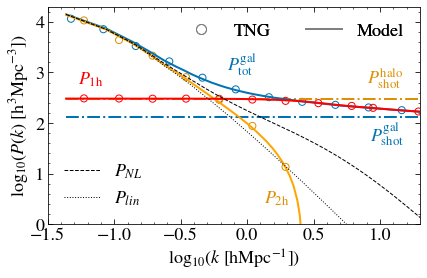

In [34]:

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

#plt.scatter(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", s=50, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2h}}$", s=50, facecolors='none', edgecolors=palette_tab10[1])

# plt.scatter(logks1,tng_tot1,  marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks_new, spaced_tot, marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks1,tng_2halo1, s=50, marker="x", c=palette_tab10[1])
# plt.scatter(logks_new, spaced_2halo, marker="x", s=50, c=palette_tab10[1])

# plt.scatter(logks1,tng_tot1,   s=100, facecolors='none', edgecolors=palette_tab10[0])
# plt.scatter(logks_new, spaced_tot,  s=100, facecolors='none', edgecolors=palette_tab10[0])
# plt.scatter(logks1,tng_2halo1,  s=50, facecolors='none', edgecolors=palette_tab10[1])
# plt.scatter(logks_new, spaced_2halo,  s=50, facecolors='none', edgecolors=palette_tab10[1])

#plt.errorbar(bin_centers, np.log10(gal_binned),yerr=gal_err_list)

#plt.errorbar(bin_centers_components,  np.log10(binned_1halo), yerr=[err_1halo_up, err_1halo_down])

#plt.scatter(logks_new, result,   s=50, facecolors='none', edgecolors='r')

# plt.scatter(bin_centers, np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])
# plt.scatter(bin_centers_components, np.log10(binned_1halo), s=50, facecolors='none', edgecolors='red')
# plt.scatter(bin_centers_components, np.log10(binned_2halo), s=50, facecolors='none', edgecolors=palette_tab10[1])


plt.scatter(np.log10(kmean_gal), np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])
plt.scatter(np.log10(kmean_1halo), np.log10(binned_1halo), s=50, facecolors='none', edgecolors='red')
plt.scatter(np.log10(kmean_2halo), np.log10(binned_2halo), s=50, facecolors='none', edgecolors=palette_tab10[1])



plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])
plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")


#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

#plt.plot(np.log10(Pk_gal10_1["k"]), np.log10(Pk_gal10_1["power"].real))
#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55), labelcolor=palette_tab10[0], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8), labelcolor=palette_tab10[1], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[2:3], loc="lower left", labelcolor=[palette_tab10[0]], handlelength=0, bbox_to_anchor=(0.4,0.6))
ax.add_artist(leg)
leg = ax.legend(handles=h[3:4], loc="lower left", labelcolor=[palette_tab10[1]], handlelength=0, bbox_to_anchor=(0.5,0))
ax.add_artist(leg)
leg = ax.legend(handles=h[4:5], loc="lower left", labelcolor=["red"], handlelength=0, bbox_to_anchor=(0,0.55))
ax.add_artist(leg)
# leg = ax.legend(handles=h[2:5], loc="lower left", labelcolor=[palette_tab10[0],palette_tab10[1],"red"], handlelength=0)
# ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0,0))
ax.add_artist(leg)



marker = Line2D([0], [0], color="grey", label="TNG", 
                linewidth=0, marker="o", markerfacecolor='none', 
                markeredgecolor="grey", markersize=10)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)


plt.xlim(-1.5,1.3)
plt.ylim(0, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in log10


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

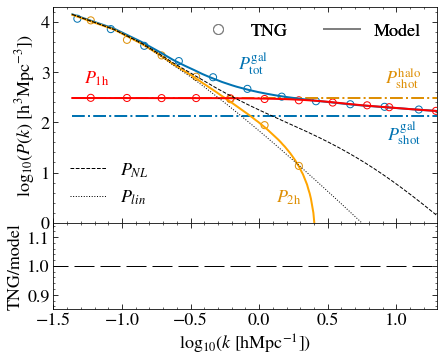

In [35]:

fig1 = plt.figure(figsize=(2*10/3, 6))
ax = fig1.add_axes((.15,.3,.8,.5))

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

plt.scatter(np.log10(kmean_gal), np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])

plt.scatter(np.log10(kmean_1halo), np.log10(binned_1halo), s=50, facecolors='none', edgecolors='red')

plt.scatter(np.log10(kmean_2halo), np.log10(binned_2halo), s=50, facecolors='none', edgecolors=palette_tab10[1])



plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])
plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55), labelcolor=palette_tab10[0], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8), labelcolor=palette_tab10[1], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[2:3], loc="lower left", labelcolor=[palette_tab10[0]], handlelength=0, bbox_to_anchor=(0.4,0.6))
ax.add_artist(leg)
leg = ax.legend(handles=h[3:4], loc="lower left", labelcolor=[palette_tab10[1]], handlelength=0, bbox_to_anchor=(0.5,0))
ax.add_artist(leg)
leg = ax.legend(handles=h[4:5], loc="lower left", labelcolor=["red"], handlelength=0, bbox_to_anchor=(0,0.55))
ax.add_artist(leg)
# leg = ax.legend(handles=h[2:5], loc="lower left", labelcolor=[palette_tab10[0],palette_tab10[1],"red"], handlelength=0)
# ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0,0))
ax.add_artist(leg)



marker = Line2D([0], [0], color="grey", label="TNG", 
                linewidth=0, marker="o", markerfacecolor='none', 
                markeredgecolor="grey", markersize=10)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)
ax.set_xticklabels([])

plt.xlim(-1.5,1.3)
plt.ylim(0, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")


frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([-1.5,1.5],[1,1],  color="k" ,linestyle=(5, (20/linewidth1, 6/linewidth1)), linewidth=linewidth1)

plt.ylabel("TNG/model")
plt.ylim(0.85,1.15)
plt.xlim(-1.5,1.3)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

(0.85, 1.15)

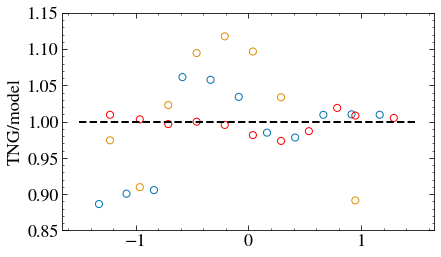

In [31]:
new_1halo = uk_2_1halo(kmean_1halo)
new_2halo = pk_from_cf(np.log10(kmean_2halo))

tot_1halo = uk_2_1halo(kmean_gal)
tot_2halo = pk_from_cf(np.log10(kmean_gal))
new_tot = tot_1halo + tot_2halo


#plt.scatter(np.log10(kmean_gal), np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])
plt.plot([-1.5,1.5], [1,1], linestyle="dashed", c="k")
plt.scatter(np.log10(kmean_gal), gal_binned/new_tot, s=50, facecolors='none', edgecolors=palette_tab10[0])
plt.scatter(np.log10(kmean_1halo), binned_1halo/new_1halo, s=50, facecolors='none', edgecolors='red')
plt.scatter(np.log10(kmean_2halo), binned_2halo/new_2halo, s=50, facecolors='none', edgecolors=palette_tab10[1])


plt.ylabel("TNG/model")
plt.ylim(0.85,1.15)

In [32]:
logks = np.arange(-1.5,1.5,0.1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in log10


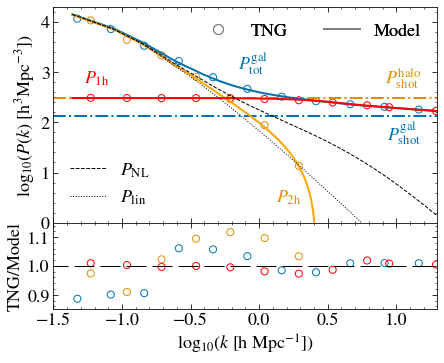

In [34]:

fig1 = plt.figure(figsize=(2*10/3, 6))
ax = fig1.add_axes((.15,.3,.8,.5))

plt.plot(logks, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

plt.scatter(np.log10(kmean_gal), np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])

plt.scatter(np.log10(kmean_1halo), np.log10(binned_1halo), s=50, facecolors='none', edgecolors='red')

plt.scatter(np.log10(kmean_2halo), np.log10(binned_2halo), s=50, facecolors='none', edgecolors=palette_tab10[1])



plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])
plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{\mathrm{NL}}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{\mathrm{lin}}$", linewidth=1)

ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55), labelcolor=palette_tab10[0], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8), labelcolor=palette_tab10[1], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[2:3], loc="lower left", labelcolor=[palette_tab10[0]], handlelength=0, bbox_to_anchor=(0.4,0.6))
ax.add_artist(leg)
leg = ax.legend(handles=h[3:4], loc="lower left", labelcolor=[palette_tab10[1]], handlelength=0, bbox_to_anchor=(0.5,0))
ax.add_artist(leg)
leg = ax.legend(handles=h[4:5], loc="lower left", labelcolor=["red"], handlelength=0, bbox_to_anchor=(0,0.55))
ax.add_artist(leg)
# leg = ax.legend(handles=h[2:5], loc="lower left", labelcolor=[palette_tab10[0],palette_tab10[1],"red"], handlelength=0)
# ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0,0))
ax.add_artist(leg)



marker = Line2D([0], [0], color="grey", label="TNG", 
                linewidth=0, marker="o", markerfacecolor='none', 
                markeredgecolor="grey", markersize=10)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)
ax.set_xticklabels([])

plt.xlim(-1.5,1.3)
plt.ylim(0, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")


frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([-1.5,1.5],[1,1],  color="k" ,linestyle=(5, (20/linewidth1, 6/linewidth1)), linewidth=linewidth1)

plt.scatter(np.log10(kmean_gal), gal_binned/new_tot, s=50, facecolors='none', edgecolors=palette_tab10[0])
plt.scatter(np.log10(kmean_1halo), binned_1halo/new_1halo, s=50, facecolors='none', edgecolors='red')
plt.scatter(np.log10(kmean_2halo)[:7], (binned_2halo/new_2halo)[:7], s=50, facecolors='none', edgecolors=palette_tab10[1])

# plt.plot(np.log10(kmean_gal), gal_binned/new_tot, c=palette_tab10[0])
# plt.plot(np.log10(kmean_1halo), binned_1halo/new_1halo, c='red')
# plt.plot(np.log10(kmean_2halo), binned_2halo/new_2halo, c=palette_tab10[1])

plt.ylabel("TNG/Model")
plt.ylim(0.85,1.15)
#plt.ylim(0.5,1.7)
plt.xlim(-1.5,1.3)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")


#plt.savefig("../figures/ps_components_model_vs_tng.pdf", format="pdf", bbox_inches="tight")

In [60]:
binned_2halo/new_2halo

array([  0.97412934,   0.90952749,   1.02280754,   1.09458522,
         1.1175678 ,   1.09669223,   1.03354151,   0.64215379,
         1.56055013,   0.89127693, -11.94353695])

In [42]:

new_1halo = uk_2_1halo(k_combined)
new_2halo = pk_from_cf(np.log10(k_combined))

tot_1halo = uk_2_1halo(k_combined)
tot_2halo = pk_from_cf(np.log10(k_combined))
new_tot = tot_1halo + tot_2halo

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in double_scalars
  # This is added back by InteractiveShellApp.init_path()
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:21: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  


KeyboardInterrupt: 

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in log10


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

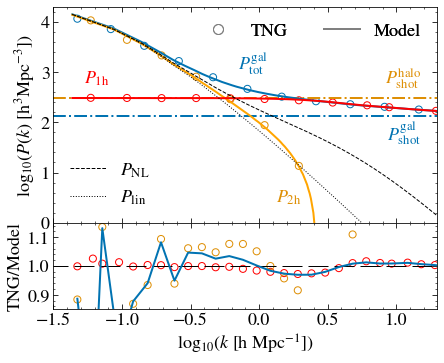

In [51]:

fig1 = plt.figure(figsize=(2*10/3, 6))
ax = fig1.add_axes((.15,.3,.8,.5))

plt.plot(logks, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

plt.scatter(np.log10(kmean_gal), np.log10(gal_binned), s=50, facecolors='none', edgecolors=palette_tab10[0])

plt.scatter(np.log10(kmean_1halo), np.log10(binned_1halo), s=50, facecolors='none', edgecolors='red')

plt.scatter(np.log10(kmean_2halo), np.log10(binned_2halo), s=50, facecolors='none', edgecolors=palette_tab10[1])



plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])
plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{\mathrm{NL}}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{\mathrm{lin}}$", linewidth=1)

ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55), labelcolor=palette_tab10[0], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8), labelcolor=palette_tab10[1], handlelength=0)
ax.add_artist(leg)
leg = ax.legend(handles=h[2:3], loc="lower left", labelcolor=[palette_tab10[0]], handlelength=0, bbox_to_anchor=(0.4,0.6))
ax.add_artist(leg)
leg = ax.legend(handles=h[3:4], loc="lower left", labelcolor=[palette_tab10[1]], handlelength=0, bbox_to_anchor=(0.5,0))
ax.add_artist(leg)
leg = ax.legend(handles=h[4:5], loc="lower left", labelcolor=["red"], handlelength=0, bbox_to_anchor=(0,0.55))
ax.add_artist(leg)
# leg = ax.legend(handles=h[2:5], loc="lower left", labelcolor=[palette_tab10[0],palette_tab10[1],"red"], handlelength=0)
# ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0,0))
ax.add_artist(leg)



marker = Line2D([0], [0], color="grey", label="TNG", 
                linewidth=0, marker="o", markerfacecolor='none', 
                markeredgecolor="grey", markersize=10)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)
ax.set_xticklabels([])

plt.xlim(-1.5,1.3)
plt.ylim(0, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")


frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([-1.5,1.5],[1,1],  color="k" ,linestyle=(5, (20/linewidth1, 6/linewidth1)), linewidth=linewidth1)

new_1halo = uk_2_1halo(kmean_1halo1)
new_2halo = pk_from_cf(np.log10(kmean_2halo1))

tot_1halo = uk_2_1halo(kmean_1halo1)
tot_2halo = pk_from_cf(np.log10(kmean_1halo1))
new_tot = tot_1halo + tot_2halo

plt.plot(np.log10(kmean_1halo1), gal_binned1/new_tot, c=palette_tab10[0])
plt.scatter(np.log10(kmean_1halo1), binned_1halo1/new_1halo, s=50, facecolors='none', edgecolors='red')
plt.scatter(np.log10(kmean_2halo1), binned_2halo1/new_2halo, s=50, facecolors='none', edgecolors=palette_tab10[1])

plt.ylabel("TNG/Model")
plt.ylim(0.85,1.15)
plt.xlim(-1.5,1.3)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in log10


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

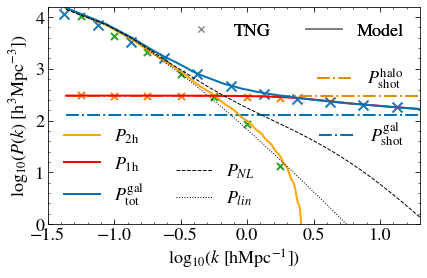

In [217]:

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

#plt.scatter(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", s=50, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2h}}$", s=50, facecolors='none', edgecolors=palette_tab10[1])

# plt.scatter(logks1,tng_tot1,  marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks_new, spaced_tot, marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks1,tng_2halo1, s=50, marker="x", c=palette_tab10[1])
# plt.scatter(logks_new, spaced_2halo, marker="x", s=50, c=palette_tab10[1])



plt.scatter(bin_centers, np.log10(gal_binned),marker="x", s=100,edgecolors=palette_tab10[0])

plt.scatter(bin_centers_components, np.log10(binned_1halo), marker="x", s=50, edgecolors='red')

plt.scatter(bin_centers_components, np.log10(binned_2halo), marker="x", s=50,edgecolors=palette_tab10[1])


#plt.scatter(logks_tng,tng_1halo, label="$P_{\mathrm{1h}}$",  s=50, facecolors='none', edgecolors='r')

# plt.scatter(logks1,tng_1halo1,  s=50, marker="x", c="red")
# plt.scatter(logks_new, result,  marker="x", s=50, c="red")


plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])

#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55))
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8))
ax.add_artist(leg)
leg = ax.legend(handles=h[2:5], loc="lower left")
ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0.3,0))
ax.add_artist(leg)

marker = Line2D([],[],color="grey", marker="x", label="TNG", linewidth=0)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)


plt.xlim(-1.5,1.3)
plt.ylim(0, 4.2)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

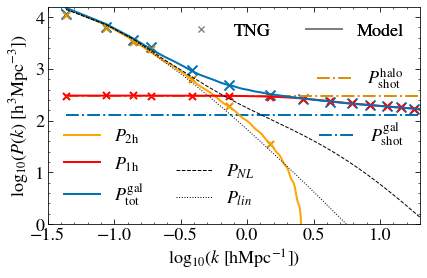

In [207]:

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

#plt.scatter(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", s=50, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2h}}$", s=50, facecolors='none', edgecolors=palette_tab10[1])

plt.scatter(logks1,tng_tot1,  marker="x", s=100, c=palette_tab10[0])
plt.scatter(logks_new, spaced_tot, marker="x", s=100, c=palette_tab10[0])
plt.scatter(logks1,tng_2halo1, s=50, marker="x", c=palette_tab10[1])
plt.scatter(logks_new, spaced_2halo, marker="x", s=50, c=palette_tab10[1])

#plt.scatter(logks_tng,tng_1halo, label="$P_{\mathrm{1h}}$",  s=50, facecolors='none', edgecolors='r')

plt.scatter(logks1,tng_1halo1,  s=50, marker="x", c="red")
plt.scatter(logks_new, result,  marker="x", s=50, c="red")


plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])

#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55))
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8))
ax.add_artist(leg)
leg = ax.legend(handles=h[2:5], loc="lower left")
ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0.3,0))
ax.add_artist(leg)

marker = Line2D([],[],color="grey", marker="x", label="TNG", linewidth=0)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)


plt.xlim(-1.5,1.3)
plt.ylim(0, 4.2)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")